In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [3]:
# Set up visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [4]:
# Loading data
data_path = Path('../data/final/train.csv')
if not data_path.exists():
    data_path = Path('data/final/train.csv')

In [5]:
df = pd.read_csv(data_path)
print(f"Dataset loaded: {len(df)} rows")
print("-" * 30)

Dataset loaded: 7102 rows
------------------------------


In [6]:
# Average word_count by category
print("Average word count per category:")
avg_words = df.groupby('category')['word_count'].mean().sort_values(ascending=False)
print(avg_words)

Average word count per category:
category
siyaset         250.545799
iqtisadiyyat    180.495660
sosial          170.139818
idman           119.210993
dunya           111.620108
Name: word_count, dtype: float64


/tmp/ipykernel_19956/64930362.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_words.index, y=avg_words.values, palette='viridis')


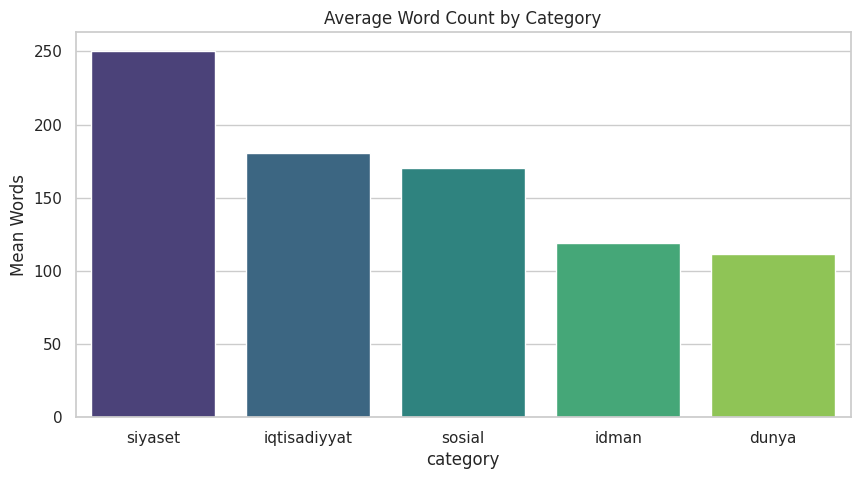

In [7]:
plt.figure(figsize=(10, 5))
sns.barplot(x=avg_words.index, y=avg_words.values, palette='viridis')
plt.title('Average Word Count by Category')
plt.ylabel('Mean Words')
plt.show()

In [8]:
# Distribution by source (how many from each website)
print("\nSource distribution:")
source_counts = df['source'].value_counts()
print(source_counts)


Source distribution:
source
qafqazinfo_az    2924
sonxeber_az      2370
report.az        1808
Name: count, dtype: int64


ValueError: unsupported format character '%' (0x25) at index 4

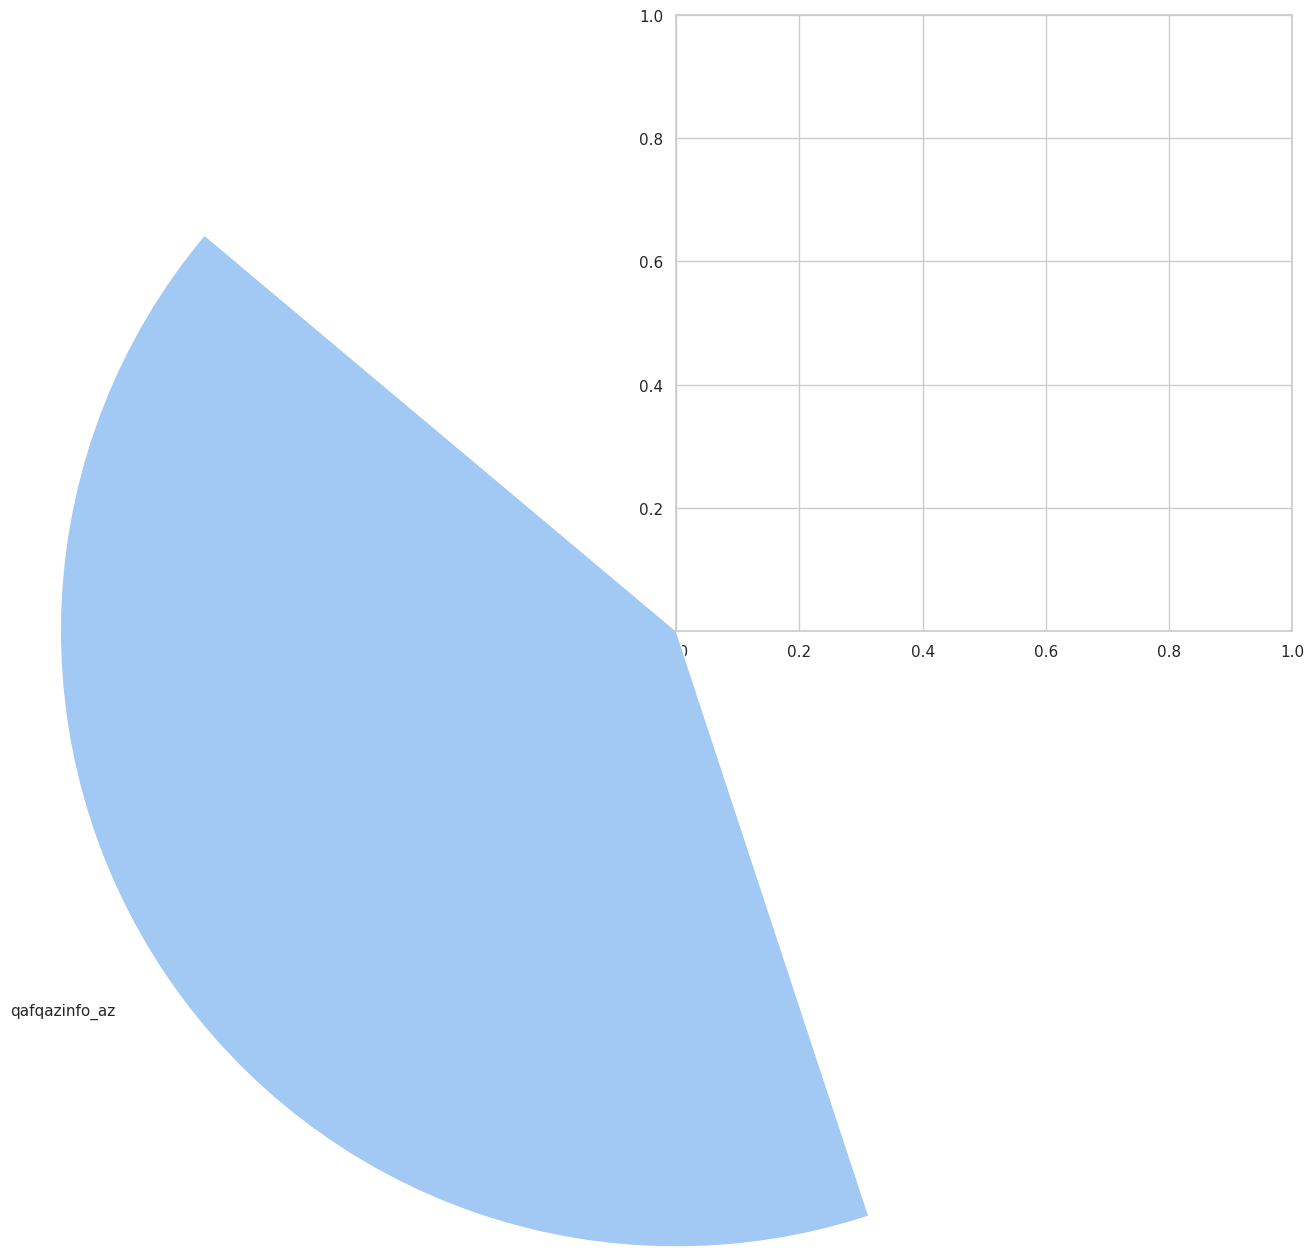

In [9]:
plt.figure(figsize=(8, 8))
plt.pie(source_counts, labels=source_counts.index, autopct='%1.1%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Source Distribution')
plt.show()

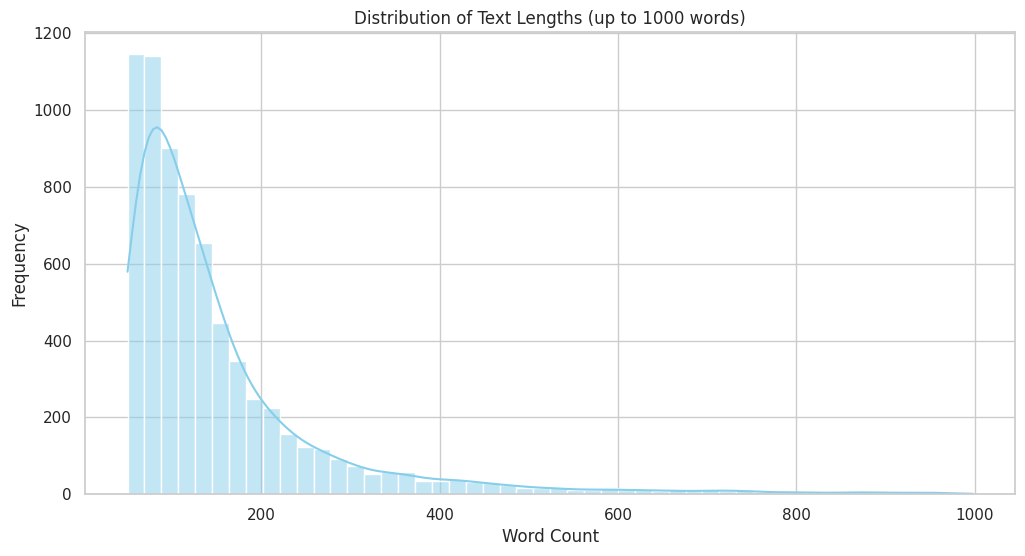

In [10]:
# Histogram of text lengths
plt.figure(figsize=(12, 6))
# Limit x to 1000 words to remove outliers and better visualize the main mass
sns.histplot(df[df['word_count'] < 1000]['word_count'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Text Lengths (up to 1000 words)')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.show()

In [11]:
# Examples of texts from each category (first 100 characters)
print("\n--- Samples from each category ---")
categories = df['category'].unique()


--- Samples from each category ---


In [12]:
for cat in categories:
    print(f"\nCATEGORY: {cat.upper()}")
    samples = df[df['category'] == cat]['content'].head(2).values
    for i, text in enumerate(samples):
        clean_text = str(text).replace('\n', ' ')[:100]
        print(f"  {i+1}. {clean_text}...")


CATEGORY: SOSIAL
  1. Məlum olduğu kimi, ali təhsil müəssisələrinə qəbul olunan abituriyentlərin qəbul olunduqları təhsil ...
  2. Bakıda yeni tikilən binaların əksəriyyəti mərkəzi istilik sisteminə qoşulmur. Ona görə də yeni tikil...

CATEGORY: DUNYA
  1. Koronavirusun ilk ortaya çıxdığı Çində yoluxma sayı yenidən artmağa başlayıb. Xəstəliyin yayılmasını...
  2. Cənubi Koreyada quşun yüksək patogenli epidemiyası aşkar edilib. Bununla əlaqədar hakimiyyət orqanla...

CATEGORY: IQTISADIYYAT
  1. Gələn il hibrid və elektrik nəqliyyat vasitələrinə gömrük rüsumlarından və əlavə dəyər vergisindən a...
  2. Yardımlı rayonu ərazisində İran-Azərbaycan yeni gömrük keçid məntəqəsinin açılması ilə bağlı hal-haz...

CATEGORY: SIYASET
  1. "Bu gün biz siyasət, iqtisadiyyat və təhlükəsizlik sahəsində fikir mübadiləsi apardıq. Ukrayna və Az...
  2. Ərzaq təhlükəsizliyi ilə bağlı bu gün əldə edilmiş razılaşmalar Azərbaycana imkan verəcək ki, öz ərz...

CATEGORY: IDMAN
  1. Neftçi" futbolçusu Xorxe Kor